# AI-Powered Network Security Incident Analysis System

### Machine Learning-Based Network Intrusion Detection

**Dataset:** UNSW-NB15

**Domain:**
- Artificial Intelligence and Machine Learning
- Network Security
- Big Data Analytics
- Natural Language Processing
- Generative AI
- Cloud Computing

## 1. Project Objective

The objective of this project is to develop an AI-powered network
security incident analysis system capable of analyzing network
traffic and identifying potential security incidents.

The system uses machine learning techniques to:

- Detect normal and malicious network traffic
- Classify different types of network attacks
- Analyze network traffic patterns
- Calculate incident risk and severity
- Provide interpretable security information

The UNSW-NB15 dataset is used for developing and evaluating the
machine learning component of the system.

## Import Libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Training Dataset

In [9]:
train_path = r"data\Training and Testing Sets\UNSW_NB15_training-set.csv"

test_path = r"data\Training and Testing Sets\UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset loaded successfully.")
print("Testing dataset loaded successfully.")

Training dataset loaded successfully.
Testing dataset loaded successfully.


## Dataset Size

In [10]:
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (175341, 45)
Testing dataset shape: (82332, 45)


## First 5 Rows

In [4]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## Column Names

In [5]:
print("Dataset Columns:\n")

for i, column in enumerate(train_df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. id
2. dur
3. proto
4. service
5. state
6. spkts
7. dpkts
8. sbytes
9. dbytes
10. rate
11. sttl
12. dttl
13. sload
14. dload
15. sloss
16. dloss
17. sinpkt
18. dinpkt
19. sjit
20. djit
21. swin
22. stcpb
23. dtcpb
24. dwin
25. tcprtt
26. synack
27. ackdat
28. smean
29. dmean
30. trans_depth
31. response_body_len
32. ct_srv_src
33. ct_state_ttl
34. ct_dst_ltm
35. ct_src_dport_ltm
36. ct_dst_sport_ltm
37. ct_dst_src_ltm
38. is_ftp_login
39. ct_ftp_cmd
40. ct_flw_http_mthd
41. ct_src_ltm
42. ct_srv_dst
43. is_sm_ips_ports
44. attack_cat
45. label


## Dataset Information

In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

## Statistical Summary

In [7]:
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


## For categorical columns

In [8]:
train_df.describe(include="all")

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,175341.000000,175341.000000,175341,175341,175341,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341,175341.000000
unique,NaN,NaN,133,13,9,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,INT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,79946,94168,82275,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56000,NaN
mean,87671.000000,1.359389,NaN,NaN,NaN,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,...,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,NaN,0.680622
std,50616.731112,6.480249,NaN,NaN,NaN,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,...,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,NaN,0.466237
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,43836.000000,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,...,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,NaN,0.000000
50%,87671.000000,0.001582,NaN,NaN,NaN,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,...,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,NaN,1.000000
75%,131506.000000,0.668069,NaN,NaN,NaN,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,...,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,NaN,1.000000


## Check Missing Values

In [53]:
missing_values = train_df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Series([], dtype: int64)


In [11]:
print("Total missing values:", train_df.isnull().sum().sum())

Total missing values: 0


## Check Duplicate Records

In [12]:
duplicate_count = train_df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


## Check Target Columns

In [13]:
print("Target columns available:")

for column in ["label", "attack_cat"]:
    if column in train_df.columns:
        print(f"✓ {column}")
    else:
        print(f"✗ {column}")

Target columns available:
✓ label
✓ attack_cat


## Normal vs Attack

In [14]:
print(train_df["label"].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64


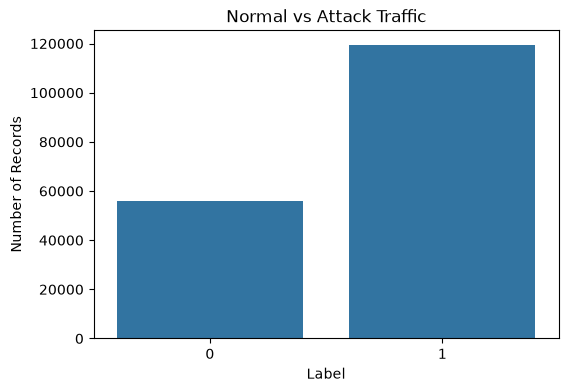

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x="label")

plt.title("Normal vs Attack Traffic")
plt.xlabel("Label")
plt.ylabel("Number of Records")

plt.show()

## Attack Categories

In [15]:
attack_counts = train_df["attack_cat"].value_counts()

print(attack_counts)

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


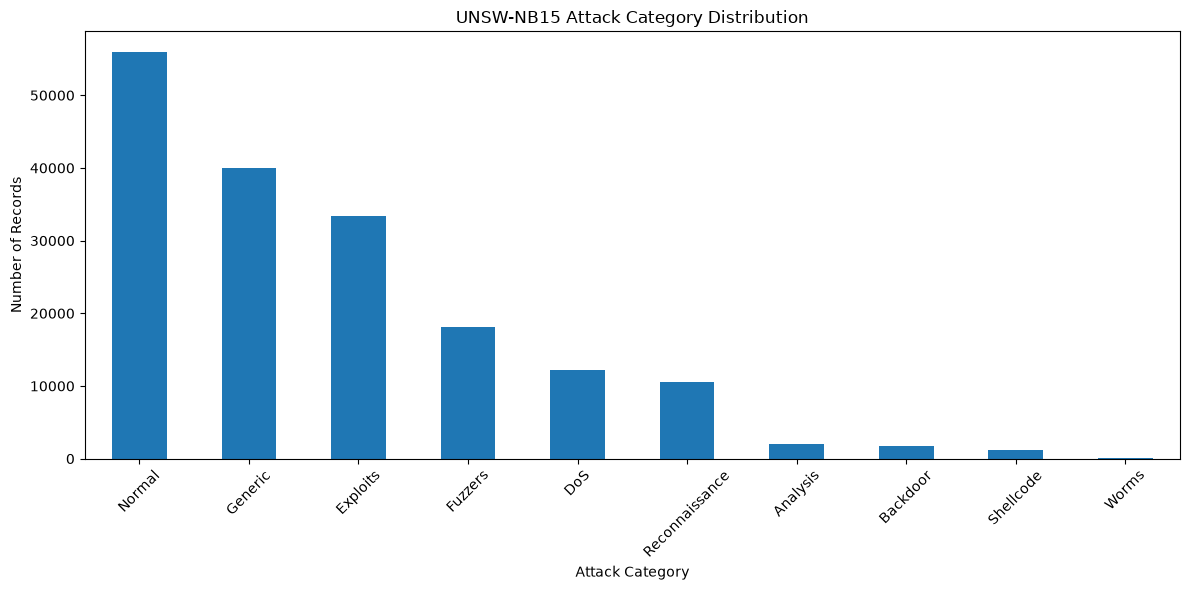

In [17]:
plt.figure(figsize=(12, 6))

attack_counts.plot(kind="bar")

plt.title("UNSW-NB15 Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
print(train_df.shape)
print(test_df.shape)

(175341, 45)
(82332, 45)


In [19]:
print(train_df.dtypes)

id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [20]:
print(train_df["attack_cat"].value_counts())

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


## Create copies

In [14]:
# Create copies of the original datasets
train = train_df.copy()
test = test_df.copy()

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (175341, 45)
Testing shape: (82332, 45)


## Check missing values

In [15]:
print("Missing values in training dataset:")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nMissing values in testing dataset:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values in training dataset:
Series([], dtype: int64)

Missing values in testing dataset:
Series([], dtype: int64)


## Check duplicate rows

In [56]:
print("Duplicate rows in training:", train.duplicated().sum())
print("Duplicate rows in testing:", test.duplicated().sum())

Duplicate rows in training: 0
Duplicate rows in testing: 0


## Separate features and targets

In [16]:
# Remove target columns from input features
X_train = train.drop(columns=["label", "attack_cat"])
X_test = test.drop(columns=["label", "attack_cat"])

# Binary classification target
y_train_binary = train["label"]
y_test_binary = test["label"]

# Multiclass classification target
y_train_multi = train["attack_cat"]
y_test_multi = test["attack_cat"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nBinary target:")
print(y_train_binary.value_counts())

print("\nMulticlass target:")
print(y_train_multi.value_counts())

X_train: (175341, 43)
X_test: (82332, 43)

Binary target:
label
1    119341
0     56000
Name: count, dtype: int64

Multiclass target:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


## Identify categorical columns

In [20]:
categorical_columns = X_train.select_dtypes(include=["object", "str"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['proto', 'service', 'state']


## Identify numerical columns

In [18]:
numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
print(numerical_columns)

Number of numerical columns: 40

Numerical columns:
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


## Encode categorical features

In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_columns])
X_test_cat = encoder.transform(X_test[categorical_columns])

print("Encoded training categorical shape:", X_train_cat.shape)
print("Encoded testing categorical shape:", X_test_cat.shape)

Encoded training categorical shape: (175341, 155)
Encoded testing categorical shape: (82332, 155)


## Scale numerical features

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_columns])
X_test_num = scaler.transform(X_test[numerical_columns])

print("Scaled numerical training shape:", X_train_num.shape)
print("Scaled numerical testing shape:", X_test_num.shape)

Scaled numerical training shape: (175341, 40)
Scaled numerical testing shape: (82332, 40)


## Combine numerical and categorical features

In [23]:
import numpy as np

X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat
])

print("Final training feature shape:", X_train_processed.shape)
print("Final testing feature shape:", X_test_processed.shape)

Final training feature shape: (175341, 195)
Final testing feature shape: (82332, 195)


## Check final data

In [62]:
print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

print("\nTraining target shape:", y_train_binary.shape)
print("Testing target shape:", y_test_binary.shape)

print("\nMulticlass training target shape:", y_train_multi.shape)
print("Multiclass testing target shape:", y_test_multi.shape)

Training data shape: (175341, 195)
Testing data shape: (82332, 195)

Training target shape: (175341,)
Testing target shape: (82332,)

Multiclass training target shape: (175341,)
Multiclass testing target shape: (82332,)


## Train Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train_binary
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


## Make predictions

In [27]:
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_logistic))

Predictions completed.
Number of predictions: 82332


## Evaluate Logistic Regression

In [28]:
accuracy = accuracy_score(y_test_binary, y_pred_logistic)
precision = precision_score(y_test_binary, y_pred_logistic)
recall = recall_score(y_test_binary, y_pred_logistic)
f1 = f1_score(y_test_binary, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression Results
---------------------------
Accuracy : 0.728453092357771
Precision: 0.7393977284568094
Recall   : 0.7826700785317215
F1 Score : 0.7604187875735396


## Classification report

In [20]:
print(classification_report(y_test_binary, y_pred_logistic,target_names=["Normal", "Attack"]))

              precision    recall  f1-score   support

      Normal       0.71      0.66      0.69     37000
      Attack       0.74      0.78      0.76     45332

    accuracy                           0.73     82332
   macro avg       0.73      0.72      0.72     82332
weighted avg       0.73      0.73      0.73     82332



## Confusion Matrix

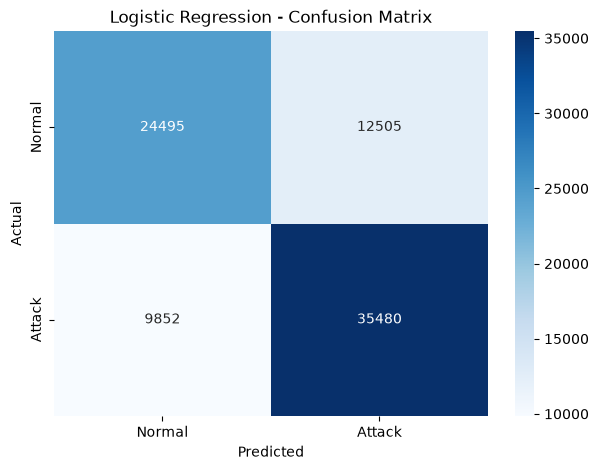

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_binary,
    y_pred_logistic
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

## Store the results

In [37]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.728453092357771, 'Precision': 0.7393977284568094, 'Recall': 0.7826700785317215, 'F1 Score': 0.7604187875735396}]


## Import Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest import successful!")

Random Forest import successful!


## Train Random Forest

In [30]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train_binary
)

print("Random Forest training completed.")

Random Forest training completed.


## Predictions

In [31]:
y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest predictions completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions completed.
Number of predictions: 82332


## Evaluation

In [32]:
rf_accuracy = accuracy_score(y_test_binary, y_pred_rf)
rf_precision = precision_score(y_test_binary, y_pred_rf)
rf_recall = recall_score(y_test_binary, y_pred_rf)
rf_f1 = f1_score(y_test_binary, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
--------------------
Accuracy : 0.6696059855220328
Precision: 0.7225522930374153
Recall   : 0.6492323303626577
F1 Score : 0.683932887153746


## Classification report

In [33]:
print(classification_report(
    y_test_binary,
    y_pred_rf,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       0.62      0.69      0.65     37000
      Attack       0.72      0.65      0.68     45332

    accuracy                           0.67     82332
   macro avg       0.67      0.67      0.67     82332
weighted avg       0.68      0.67      0.67     82332



## Confusion matrix

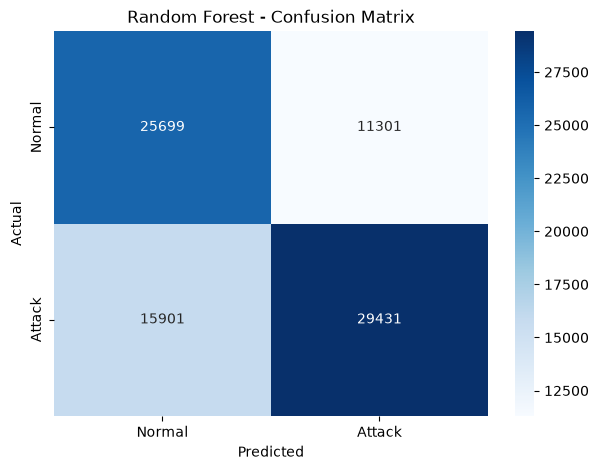

In [34]:
cm_rf = confusion_matrix(
    y_test_binary,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

## Save the result

In [38]:
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
})

print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.728453092357771, 'Precision': 0.7393977284568094, 'Recall': 0.7826700785317215, 'F1 Score': 0.7604187875735396}, {'Model': 'Random Forest', 'Accuracy': 0.6696059855220328, 'Precision': 0.7225522930374153, 'Recall': 0.6492323303626577, 'F1 Score': 0.683932887153746}]


## XGBoost

In [40]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)


In [11]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


## Create XGBoost model

In [12]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created.")

XGBoost model created.


## Train

In [13]:
xgb_model.fit(
    X_train_processed,
    y_train_binary
)

print("XGBoost training completed.")

NameError: name 'X_train_processed' is not defined

## Predictions

In [44]:
y_pred_xgb = xgb_model.predict(X_test_processed)

print("XGBoost predictions completed.")
print("Number of predictions:", len(y_pred_xgb))

XGBoost predictions completed.
Number of predictions: 82332


## Evaluation

In [45]:
xgb_accuracy = accuracy_score(y_test_binary, y_pred_xgb)
xgb_precision = precision_score(y_test_binary, y_pred_xgb)
xgb_recall = recall_score(y_test_binary, y_pred_xgb)
xgb_f1 = f1_score(y_test_binary, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

XGBoost Results
----------------
Accuracy : 0.5264903075353446
Precision: 0.6069202520130723
Recall   : 0.3973793346863143
F1 Score : 0.48029008305227094


## Classification report

In [46]:
print(classification_report(
    y_test_binary,
    y_pred_xgb,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       0.48      0.68      0.57     37000
      Attack       0.61      0.40      0.48     45332

    accuracy                           0.53     82332
   macro avg       0.54      0.54      0.52     82332
weighted avg       0.55      0.53      0.52     82332



## Confusion matrix

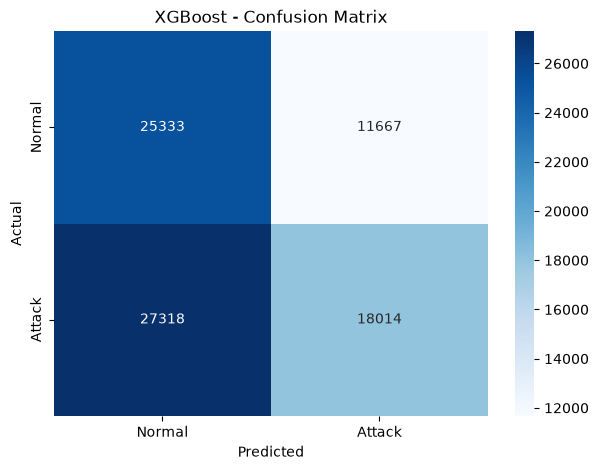

In [47]:
cm_xgb = confusion_matrix(
    y_test_binary,
    y_pred_xgb
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

plt.show()

## Add XGBoost to results

In [48]:
results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1
})

print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.728453092357771, 'Precision': 0.7393977284568094, 'Recall': 0.7826700785317215, 'F1 Score': 0.7604187875735396}, {'Model': 'Random Forest', 'Accuracy': 0.6696059855220328, 'Precision': 0.7225522930374153, 'Recall': 0.6492323303626577, 'F1 Score': 0.683932887153746}, {'Model': 'XGBoost', 'Accuracy': 0.5264903075353446, 'Precision': 0.6069202520130723, 'Recall': 0.3973793346863143, 'F1 Score': 0.48029008305227094}]


## Create comparison table

In [49]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.728453,0.739398,0.782670,0.760419
1,Random Forest,0.669606,0.722552,0.649232,0.683933
2,XGBoost,0.526490,0.606920,0.397379,0.480290


## Encode attack categories

In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_multi_encoded = label_encoder.fit_transform(y_train_multi)
y_test_multi_encoded = label_encoder.transform(y_test_multi)

print("Attack categories:")
for i, category in enumerate(label_encoder.classes_):
    print(i, "=", category)

Attack categories:
0 = Analysis
1 = Backdoor
2 = DoS
3 = Exploits
4 = Fuzzers
5 = Generic
6 = Normal
7 = Reconnaissance
8 = Shellcode
9 = Worms


## Verify encoding

In [51]:
print("Encoded training target shape:", y_train_multi_encoded.shape)
print("Encoded testing target shape:", y_test_multi_encoded.shape)

print("\nEncoded class distribution:")
print(pd.Series(y_train_multi_encoded).value_counts().sort_index())

Encoded training target shape: (175341,)
Encoded testing target shape: (82332,)

Encoded class distribution:
0     2000
1     1746
2    12264
3    33393
4    18184
5    40000
6    56000
7    10491
8     1133
9      130
Name: count, dtype: int64


## Train Multiclass Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression

multi_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

multi_logistic_model.fit(
    X_train_processed,
    y_train_multi_encoded
)

print("Multiclass Logistic Regression training completed.")

Multiclass Logistic Regression training completed.


## Make multiclass predictions

In [66]:
y_pred_multi_logistic = multi_logistic_model.predict(
    X_test_processed
)

print("Multiclass predictions completed.")
print("Number of predictions:", len(y_pred_multi_logistic))

Multiclass predictions completed.
Number of predictions: 82332


## Multiclass evaluation

In [67]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

multi_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_logistic
)

multi_precision, multi_recall, multi_f1, _ = precision_recall_fscore_support(
    y_test_multi_encoded,
    y_pred_multi_logistic,
    average="weighted",
    zero_division=0
)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test_multi_encoded,
    y_pred_multi_logistic,
    average="macro",
    zero_division=0
)

print("Multiclass Logistic Regression Results")
print("--------------------------------------")
print("Accuracy          :", multi_accuracy)
print("Weighted Precision:", multi_precision)
print("Weighted Recall   :", multi_recall)
print("Weighted F1       :", multi_f1)
print("Macro Precision   :", macro_precision)
print("Macro Recall      :", macro_recall)
print("Macro F1          :", macro_f1)

Multiclass Logistic Regression Results
--------------------------------------
Accuracy          : 0.48882572997133555
Weighted Precision: 0.6200623088685976
Weighted Recall   : 0.48882572997133555
Weighted F1       : 0.48044157507824237
Macro Precision   : 0.31393786314038347
Macro Recall      : 0.22151233264126802
Macro F1          : 0.2118013458541251


## Detailed classification report

In [68]:
print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_logistic,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

      Analysis       0.02      0.01      0.01       677
      Backdoor       0.00      0.00      0.00       583
           DoS       0.55      0.01      0.02      4089
      Exploits       0.50      0.69      0.58     11132
       Fuzzers       0.08      0.24      0.12      6062
       Generic       1.00      0.23      0.37     18871
        Normal       0.61      0.69      0.65     37000
Reconnaissance       0.38      0.35      0.36      3496
     Shellcode       0.00      0.00      0.00       378
         Worms       0.00      0.00      0.00        44

      accuracy                           0.49     82332
     macro avg       0.31      0.22      0.21     82332
  weighted avg       0.62      0.49      0.48     82332



## Multiclass confusion matrix

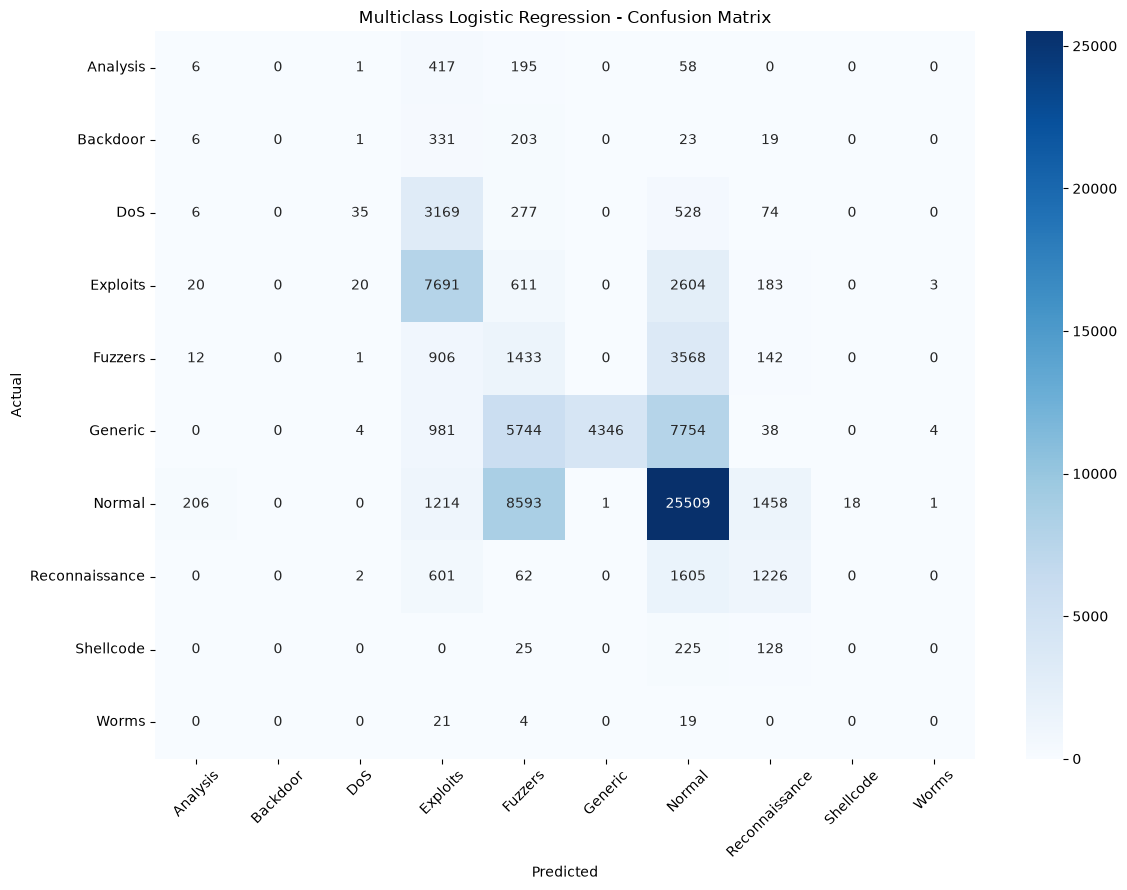

In [69]:
cm_multi = confusion_matrix(
    y_test_multi_encoded,
    y_pred_multi_logistic
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multiclass Logistic Regression - Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Save multiclass results

In [70]:
multi_results = []

multi_results.append({
    "Model": "Logistic Regression",
    "Accuracy": multi_accuracy,
    "Weighted Precision": multi_precision,
    "Weighted Recall": multi_recall,
    "Weighted F1": multi_f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1
})

multi_results_df = pd.DataFrame(multi_results)

multi_results_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.488826,0.620062,0.488826,0.480442,0.313938,0.221512,0.211801


## Multiclass Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

multi_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

multi_rf_model.fit(
    X_train_processed,
    y_train_multi_encoded
)

print("Multiclass Random Forest training completed.")

Multiclass Random Forest training completed.


In [73]:
y_pred_multi_rf = multi_rf_model.predict(X_test_processed)

print("Multiclass Random Forest predictions completed.")
print("Number of predictions:", len(y_pred_multi_rf))

Multiclass Random Forest predictions completed.
Number of predictions: 82332


In [74]:
multi_rf_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_rf
)

multi_rf_precision, multi_rf_recall, multi_rf_f1, _ = precision_recall_fscore_support(
    y_test_multi_encoded,
    y_pred_multi_rf,
    average="weighted",
    zero_division=0
)

multi_rf_macro_precision, multi_rf_macro_recall, multi_rf_macro_f1, _ = precision_recall_fscore_support(
    y_test_multi_encoded,
    y_pred_multi_rf,
    average="macro",
    zero_division=0
)

print("Multiclass Random Forest Results")
print("--------------------------------")
print("Accuracy          :", multi_rf_accuracy)
print("Weighted Precision:", multi_rf_precision)
print("Weighted Recall   :", multi_rf_recall)
print("Weighted F1       :", multi_rf_f1)
print("Macro Precision   :", multi_rf_macro_precision)
print("Macro Recall      :", multi_rf_macro_recall)
print("Macro F1          :", multi_rf_macro_f1)

Multiclass Random Forest Results
--------------------------------
Accuracy          : 0.6442695428266044
Weighted Precision: 0.7132943763857634
Weighted Recall   : 0.6442695428266044
Weighted F1       : 0.6638027447551844
Macro Precision   : 0.45211505923432743
Macro Recall      : 0.33344643700561244
Macro F1          : 0.34382342908603986


## Multiclass Random Forest Classification Report

In [75]:
# Cell 54: Multiclass Random Forest Classification Report

print("Multiclass Random Forest Classification Report")
print("===============================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_rf,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Multiclass Random Forest Classification Report
                precision    recall  f1-score   support

      Analysis       0.01      0.03      0.02       677
      Backdoor       0.02      0.11      0.03       583
           DoS       0.20      0.10      0.13      4089
      Exploits       0.67      0.40      0.50     11132
       Fuzzers       0.21      0.42      0.28      6062
       Generic       1.00      0.96      0.98     18871
        Normal       0.73      0.71      0.72     37000
Reconnaissance       0.91      0.32      0.47      3496
     Shellcode       0.27      0.26      0.27       378
         Worms       0.50      0.02      0.04        44

      accuracy                           0.64     82332
     macro avg       0.45      0.33      0.34     82332
  weighted avg       0.71      0.64      0.66     82332



## Multiclass Random Forest Confusion Matrix

<Figure size 1000x800 with 0 Axes>

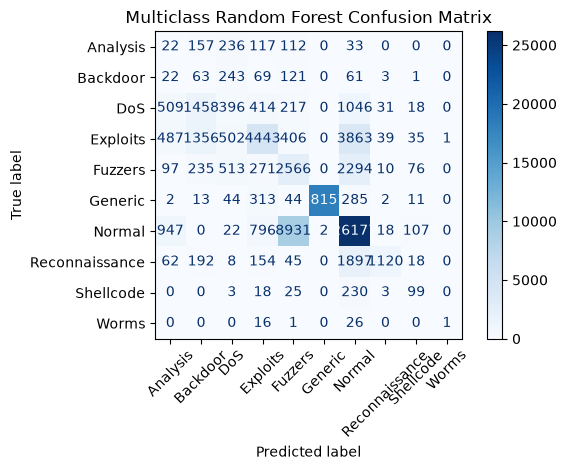

In [76]:
# Cell 55: Multiclass Random Forest Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test_multi_encoded,
    y_pred_multi_rf,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Multiclass Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## Store Multiclass Random Forest Results

In [77]:
# Cell 56: Store Multiclass Random Forest Results

multiclass_results = []

multiclass_results.append({
    "Model": "Logistic Regression",
    "Accuracy": multi_accuracy,
    "Weighted Precision": multi_precision,
    "Weighted Recall": multi_recall,
    "Weighted F1": multi_f1,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1
})

multiclass_results.append({
    "Model": "Random Forest",
    "Accuracy": multi_rf_accuracy,
    "Weighted Precision": multi_rf_precision,
    "Weighted Recall": multi_rf_recall,
    "Weighted F1": multi_rf_f1,
    "Macro Precision": multi_rf_macro_precision,
    "Macro Recall": multi_rf_macro_recall,
    "Macro F1": multi_rf_macro_f1
})

print("Multiclass results stored successfully.")

Multiclass results stored successfully.


## Multiclass Model Compariso

In [79]:
# Cell 57: Multiclass Model Comparison

multiclass_results_df = pd.DataFrame(multiclass_results)

multiclass_results_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.488826,0.620062,0.488826,0.480442,0.313938,0.221512,0.211801
1,Random Forest,0.644270,0.713294,0.644270,0.663803,0.452115,0.333446,0.343823


## Multiclass XGBoost

In [80]:
# Cell 58: Multiclass XGBoost Model

from xgboost import XGBClassifier

multi_xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

multi_xgb_model.fit(
    X_train_processed,
    y_train_multi_encoded
)

print("Multiclass XGBoost training completed.")

Multiclass XGBoost training completed.


## XGBoost Predictions

In [81]:
# Cell 59: Multiclass XGBoost Predictions

y_pred_multi_xgb = multi_xgb_model.predict(X_test_processed)

print("Multiclass XGBoost predictions completed.")
print("Number of predictions:", len(y_pred_multi_xgb))

Multiclass XGBoost predictions completed.
Number of predictions: 82332


## Multiclass XGBoost Evaluation

In [82]:
# Cell 60: Multiclass XGBoost Evaluation

multi_xgb_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_xgb
)

multi_xgb_precision, multi_xgb_recall, multi_xgb_f1, _ = precision_recall_fscore_support(
    y_test_multi_encoded,
    y_pred_multi_xgb,
    average="weighted",
    zero_division=0
)

multi_xgb_macro_precision, multi_xgb_macro_recall, multi_xgb_macro_f1, _ = precision_recall_fscore_support(
    y_test_multi_encoded,
    y_pred_multi_xgb,
    average="macro",
    zero_division=0
)

print("Multiclass XGBoost Results")
print("--------------------------")
print("Accuracy          :", multi_xgb_accuracy)
print("Weighted Precision:", multi_xgb_precision)
print("Weighted Recall   :", multi_xgb_recall)
print("Weighted F1       :", multi_xgb_f1)
print("Macro Precision   :", multi_xgb_macro_precision)
print("Macro Recall      :", multi_xgb_macro_recall)
print("Macro F1          :", multi_xgb_macro_f1)

Multiclass XGBoost Results
--------------------------
Accuracy          : 0.4811616382451538
Weighted Precision: 0.5880333426296115
Weighted Recall   : 0.4811616382451538
Weighted F1       : 0.4726067869922337
Macro Precision   : 0.424944117777422
Macro Recall      : 0.2671150332008828
Macro F1          : 0.28589749092521416


## XGBoost Classification Report

In [83]:
# Cell 61: Multiclass XGBoost Classification Report

print("Multiclass XGBoost Classification Report")
print("=========================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_xgb,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Multiclass XGBoost Classification Report
                precision    recall  f1-score   support

      Analysis       0.01      0.04      0.01       677
      Backdoor       0.20      0.08      0.12       583
           DoS       0.26      0.01      0.02      4089
      Exploits       0.46      0.32      0.37     11132
       Fuzzers       0.21      0.39      0.27      6062
       Generic       1.00      0.34      0.50     18871
        Normal       0.50      0.71      0.59     37000
Reconnaissance       0.94      0.29      0.45      3496
     Shellcode       0.21      0.30      0.24       378
         Worms       0.47      0.20      0.29        44

      accuracy                           0.48     82332
     macro avg       0.42      0.27      0.29     82332
  weighted avg       0.59      0.48      0.47     82332



In [84]:
# Cell 84: Final Multiclass Model Comparison

final_multiclass_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": multi_accuracy,
        "Weighted Precision": multi_precision,
        "Weighted Recall": multi_recall,
        "Weighted F1": multi_f1,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": multi_rf_accuracy,
        "Weighted Precision": multi_rf_precision,
        "Weighted Recall": multi_rf_recall,
        "Weighted F1": multi_rf_f1,
        "Macro Precision": multi_rf_macro_precision,
        "Macro Recall": multi_rf_macro_recall,
        "Macro F1": multi_rf_macro_f1
    },
    {
        "Model": "XGBoost",
        "Accuracy": multi_xgb_accuracy,
        "Weighted Precision": multi_xgb_precision,
        "Weighted Recall": multi_xgb_recall,
        "Weighted F1": multi_xgb_f1,
        "Macro Precision": multi_xgb_macro_precision,
        "Macro Recall": multi_xgb_macro_recall,
        "Macro F1": multi_xgb_macro_f1
    }
])

final_multiclass_results.round(4)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.4888,0.6201,0.4888,0.4804,0.3139,0.2215,0.2118
1,Random Forest,0.6443,0.7133,0.6443,0.6638,0.4521,0.3334,0.3438
2,XGBoost,0.4812,0.5880,0.4812,0.4726,0.4249,0.2671,0.2859


## Multiclass Model Comparison Visualization

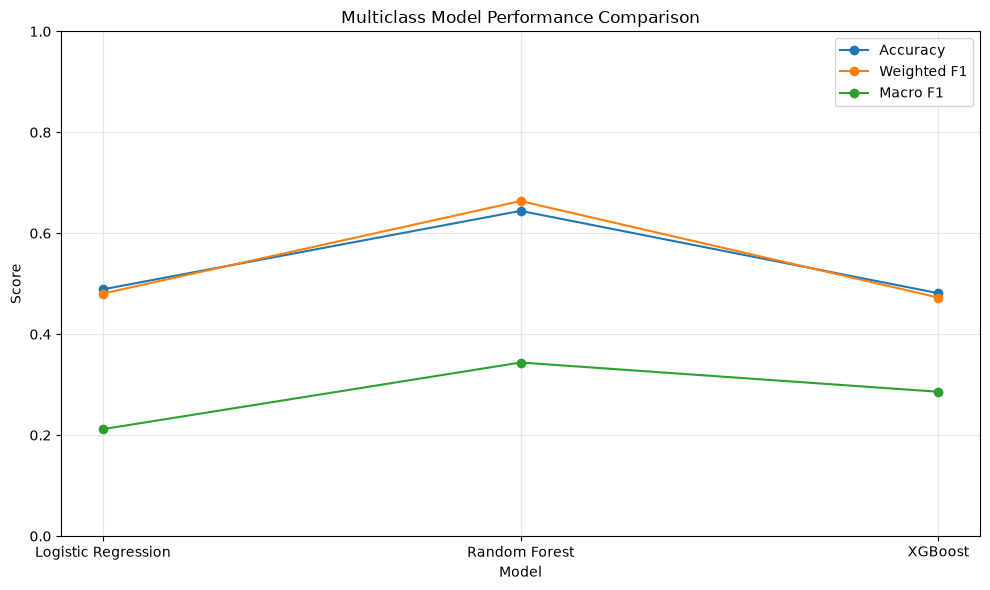

In [85]:
# Cell 85: Multiclass Model Performance Comparison

import matplotlib.pyplot as plt

models = final_multiclass_results["Model"]

plt.figure(figsize=(10, 6))

plt.plot(
    models,
    final_multiclass_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    models,
    final_multiclass_results["Weighted F1"],
    marker="o",
    label="Weighted F1"
)

plt.plot(
    models,
    final_multiclass_results["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Multiclass Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multiclass Confusion Matrix for XGBoost

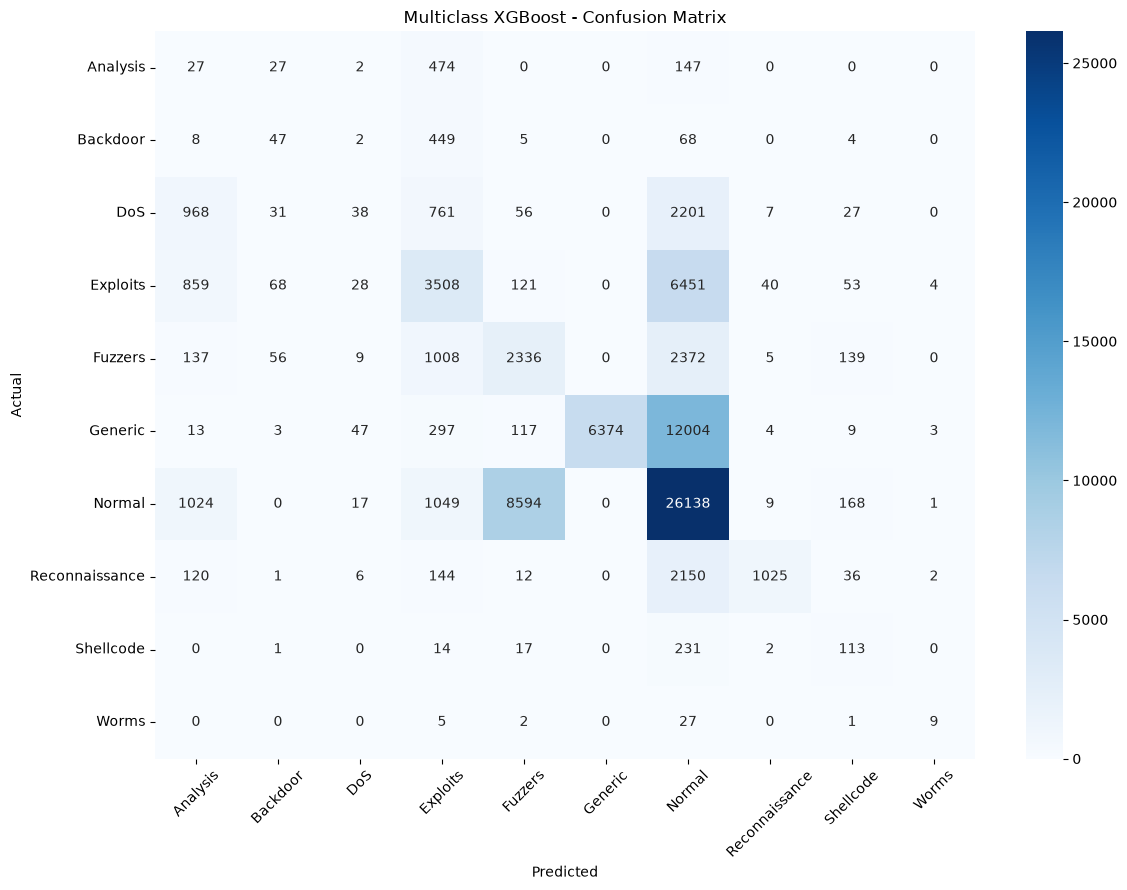

In [86]:
# Cell 86: Multiclass XGBoost Confusion Matrix

cm_multi_xgb = confusion_matrix(
    y_test_multi_encoded,
    y_pred_multi_xgb
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_multi_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multiclass XGBoost - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Multiclass Logistic Regression Confusion Matrix

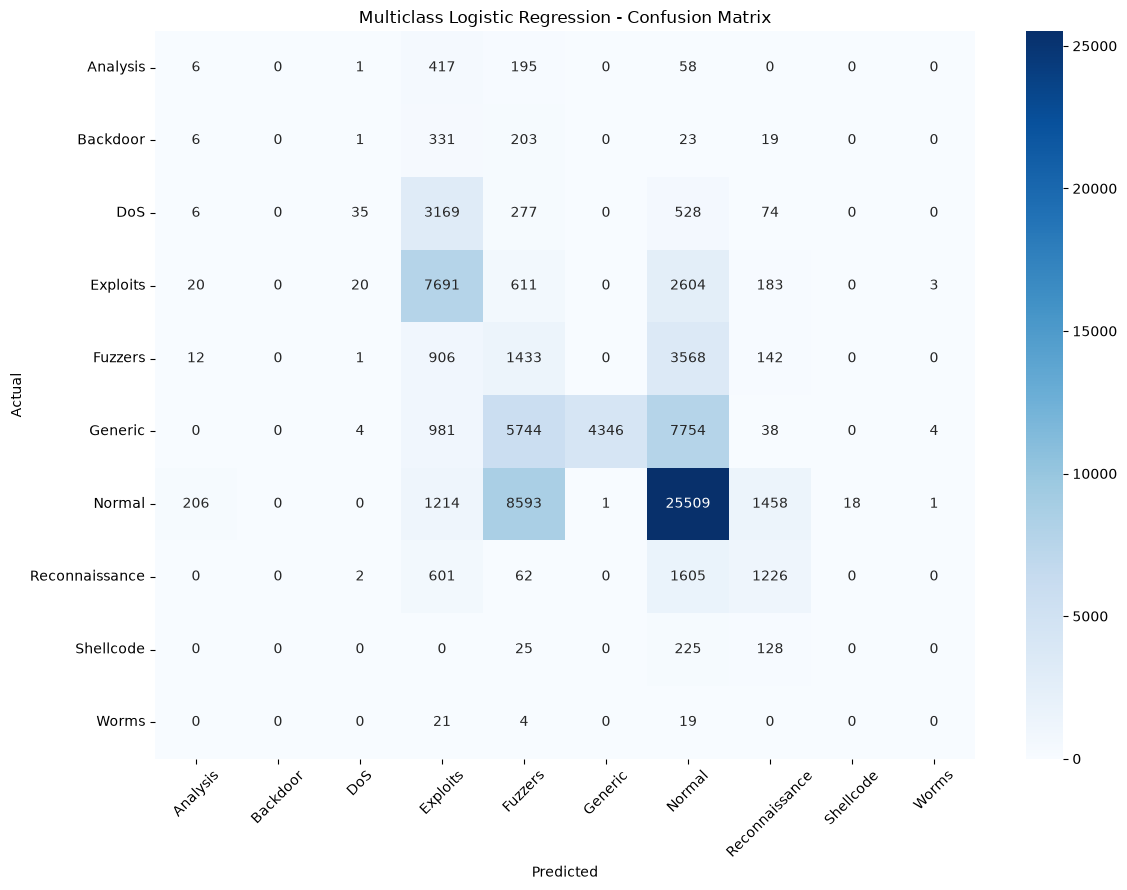

In [87]:
# Cell 87: Multiclass Logistic Regression Confusion Matrix

cm_multi_logistic = confusion_matrix(
    y_test_multi_encoded,
    y_pred_multi_logistic
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_multi_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multiclass Logistic Regression - Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Select Experimental Best Model

In [88]:
# Cell 88: Select Best Multiclass Model Based on Weighted F1

best_model_index = final_multiclass_results["Weighted F1"].idxmax()

best_multiclass_model_name = final_multiclass_results.loc[
    best_model_index,
    "Model"
]

print("Best Multiclass Model based on Weighted F1:")
print(best_multiclass_model_name)

print("\nPerformance:")
print(
    final_multiclass_results.loc[
        best_model_index
    ]
)

Best Multiclass Model based on Weighted F1:
Random Forest

Performance:
Model                 Random Forest
Accuracy                    0.64427
Weighted Precision         0.713294
Weighted Recall             0.64427
Weighted F1                0.663803
Macro Precision            0.452115
Macro Recall               0.333446
Macro F1                   0.343823
Name: 1, dtype: object


## Random Forest Feature Importance

In [90]:
# Cell 89: Random Forest Feature Importance

# Get feature names from the preprocessing encoder
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

# Combine numerical and categorical feature names
feature_names = numerical_columns + list(categorical_feature_names)

# Get feature importance from Random Forest
importances = multi_rf_model.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Number of features:", len(feature_names))
print("Number of importances:", len(importances))

print("\nTop 20 Important Features")
print("=========================")

display(feature_importance_df.head(20))

Number of features: 195
Number of importances: 195

Top 20 Important Features


,Feature,Importance
0,id,0.225486
4,sbytes,0.055795
38,ct_srv_dst,0.044382
24,smean,0.038593
33,ct_dst_src_ltm,0.037798
28,ct_srv_src,0.036302
7,sttl,0.036004
29,ct_state_ttl,0.032610
32,ct_dst_sport_ltm,0.031154
31,ct_src_dport_ltm,0.030801


## Check id Relationship With Attack Classes

In [91]:
# Cell 90: Analyze ID Feature

print("ID Statistics")
print("==============")

print("Minimum ID:", train["id"].min())
print("Maximum ID:", train["id"].max())
print("Unique IDs:", train["id"].nunique())
print("Training rows:", len(train))

print("\nID correlation with binary label:")
print(train[["id", "label"]].corr())

ID Statistics
Minimum ID: 1
Maximum ID: 175341
Unique IDs: 175341
Training rows: 175341

ID correlation with binary label:
             id     label
id     1.000000  0.727173
label  0.727173  1.000000


## ID Distribution Across Attack Categories

In [95]:
print("Mean ID by Attack Category")
print("===========================")

id_by_attack = (
    train.groupby("attack_cat")["id"]
    .agg(["count", "min", "max", "mean"])
    .sort_values("mean")
)

display(id_by_attack)

Mean ID by Attack Category


,count,min,max,mean
attack_cat,,,,
Normal,56000,1,115964,33939.199286
Analysis,2000,47933,172533,90862.180000
Backdoor,1746,47912,174021,93415.512027
Fuzzers,18184,48018,175002,93789.170974
Exploits,33393,48933,175306,94704.938191
Worms,130,49960,168944,95146.576923
Shellcode,1133,48814,175338,95849.388350
Reconnaissance,10491,48867,175180,96434.176151
DoS,12264,49000,175249,96876.255545


## Feature Importance Without id

In [93]:
# Cell 92: Feature Importance Excluding ID

feature_importance_without_id = feature_importance_df[
    feature_importance_df["Feature"] != "id"
].copy()

print("Top 20 Features Excluding ID")
print("============================")

display(
    feature_importance_without_id.head(20)
)

Top 20 Features Excluding ID


,Feature,Importance
4,sbytes,0.055795
38,ct_srv_dst,0.044382
24,smean,0.038593
33,ct_dst_src_ltm,0.037798
28,ct_srv_src,0.036302
7,sttl,0.036004
29,ct_state_ttl,0.032610
32,ct_dst_sport_ltm,0.031154
31,ct_src_dport_ltm,0.030801
175,service_dns,0.027325


## Feature Importance Visualization

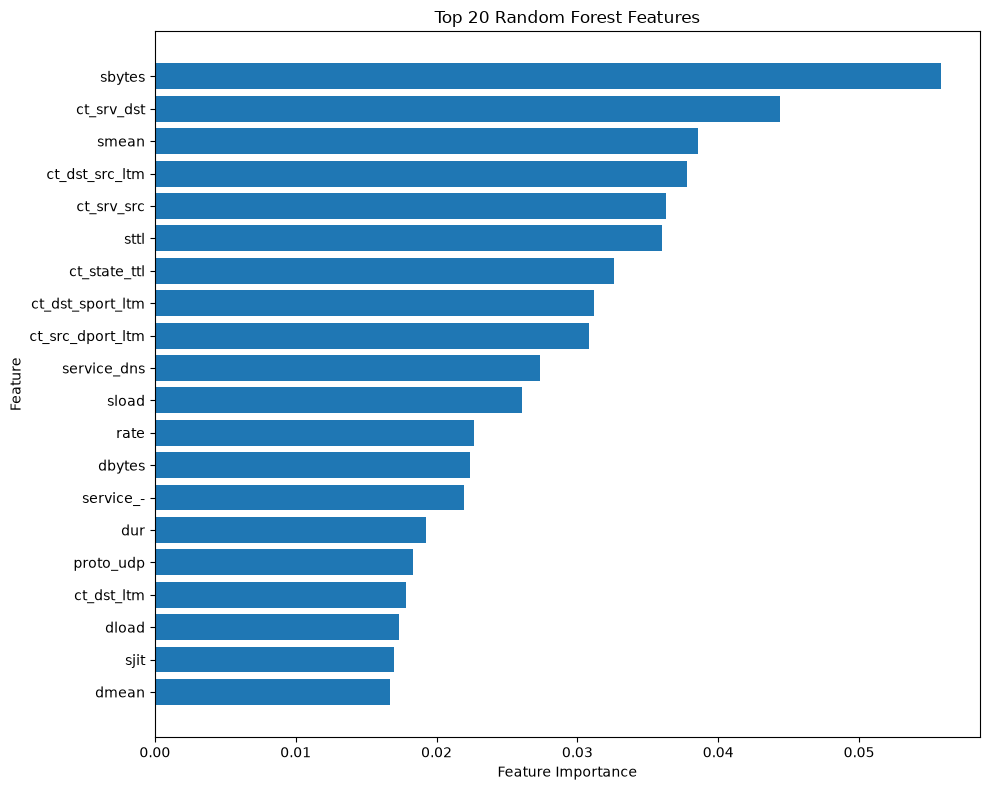

In [94]:
# Cell 93: Top 20 Feature Importance Visualization

top_features = feature_importance_without_id.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Features")
plt.tight_layout()
plt.show()

## Remove ID From Training and Testing Data

In [31]:
# Cell 94: Remove ID Feature

# Remove ID from the raw feature datasets
X_train_no_id = train.drop(
    columns=["label", "attack_cat", "id"]
)

X_test_no_id = test.drop(
    columns=["label", "attack_cat", "id"]
)

print("Training features without ID:", X_train_no_id.shape)
print("Testing features without ID:", X_test_no_id.shape)

Training features without ID: (175341, 42)
Testing features without ID: (82332, 42)


## Identify Categorical and Numerical Features

In [33]:
# Cell 95: Identify Features Without ID

categorical_columns_no_id = [
    "proto",
    "service",
    "state"
]

numerical_columns_no_id = [
    col for col in X_train_no_id.columns
    if col not in categorical_columns_no_id
]

print("Number of categorical features:", len(categorical_columns_no_id))
print("Number of numerical features:", len(numerical_columns_no_id))

print("\nCategorical features:")
print(categorical_columns_no_id)

print("\nNumber of numerical features:")
print(len(numerical_columns_no_id))

Number of categorical features: 3
Number of numerical features: 39

Categorical features:
['proto', 'service', 'state']

Number of numerical features:
39


## Encode Categorical Features Without ID

In [34]:
# Cell 96: One-Hot Encoding Without ID

from sklearn.preprocessing import OneHotEncoder

encoder_no_id = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_categorical_no_id = encoder_no_id.fit_transform(
    X_train_no_id[categorical_columns_no_id]
)

X_test_categorical_no_id = encoder_no_id.transform(
    X_test_no_id[categorical_columns_no_id]
)

print("Encoded training categorical shape:",
      X_train_categorical_no_id.shape)

print("Encoded testing categorical shape:",
      X_test_categorical_no_id.shape)

Encoded training categorical shape: (175341, 155)
Encoded testing categorical shape: (82332, 155)


## Scale Numerical Features Without ID

In [35]:
# Cell 97: Scale Numerical Features Without ID

from sklearn.preprocessing import StandardScaler

scaler_no_id = StandardScaler()

X_train_numerical_no_id = scaler_no_id.fit_transform(
    X_train_no_id[numerical_columns_no_id]
)

X_test_numerical_no_id = scaler_no_id.transform(
    X_test_no_id[numerical_columns_no_id]
)

print("Scaled training numerical shape:",
      X_train_numerical_no_id.shape)

print("Scaled testing numerical shape:",
      X_test_numerical_no_id.shape)

Scaled training numerical shape: (175341, 39)
Scaled testing numerical shape: (82332, 39)


## Combine Processed Features

In [37]:
# Cell 98: Combine Numerical and Categorical Features

import numpy as np

X_train_processed_no_id = np.hstack([
    X_train_numerical_no_id,
    X_train_categorical_no_id
])

X_test_processed_no_id = np.hstack([
    X_test_numerical_no_id,
    X_test_categorical_no_id
])

print("Final training feature shape:", X_train_processed_no_id.shape)
print("Final testing feature shape:", X_test_processed_no_id.shape)

Final training feature shape: (175341, 194)
Final testing feature shape: (82332, 194)


## Verify No ID Leakage

In [39]:
# Cell 99: Verify ID Has Been Removed

print("ID in training columns:",
      "id" in X_train_no_id.columns)

print("ID in testing columns:",
      "id" in X_test_no_id.columns)

print("Processed training shape:",
      X_train_processed_no_id.shape)

print("Processed testing shape:",
      X_test_processed_no_id.shape)

ID in training columns: False
ID in testing columns: False
Processed training shape: (175341, 194)
Processed testing shape: (82332, 194)


## Retrain Multiclass Random Forest Without ID

In [48]:
# Cell 100: Retrain Multiclass Random Forest Without ID

multi_rf_model_no_id = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

multi_rf_model_no_id.fit(
    X_train_processed_no_id,
    y_train_multi_encoded
)

print("Random Forest training without ID completed.")

Random Forest training without ID completed.


## Random Forest Predictions Without ID

In [57]:
# Cell 101: Random Forest Predictions Without ID

y_pred_multi_rf_no_id = multi_rf_model_no_id.predict(
    X_test_processed_no_id
)

print("Random Forest predictions completed.")
print("Number of predictions:", len(y_pred_multi_rf_no_id))

Random Forest predictions completed.
Number of predictions: 82332


## Random Forest Evaluation Without ID

In [58]:
# Cell 102: Random Forest Evaluation Without ID

rf_no_id_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_rf_no_id
)

rf_no_id_precision, rf_no_id_recall, rf_no_id_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_rf_no_id,
        average="weighted",
        zero_division=0
    )
)

rf_no_id_macro_precision, rf_no_id_macro_recall, rf_no_id_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_rf_no_id,
        average="macro",
        zero_division=0
    )
)

print("Random Forest Without ID Results")
print("---------------------------------")
print("Accuracy          :", rf_no_id_accuracy)
print("Weighted Precision:", rf_no_id_precision)
print("Weighted Recall   :", rf_no_id_recall)
print("Weighted F1       :", rf_no_id_f1)
print("Macro Precision   :", rf_no_id_macro_precision)
print("Macro Recall      :", rf_no_id_macro_recall)
print("Macro F1          :", rf_no_id_macro_f1)

Random Forest Without ID Results
---------------------------------
Accuracy          : 0.7544332701744157
Weighted Precision: 0.8392373937249994
Weighted Recall   : 0.7544332701744157
Weighted F1       : 0.775999942506124
Macro Precision   : 0.5332496486508899
Macro Recall      : 0.48282976921351156
Macro F1          : 0.4584505466016668


In [59]:
# Cell 102: Random Forest Evaluation Without ID

rf_no_id_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_rf_no_id
)

rf_no_id_precision, rf_no_id_recall, rf_no_id_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_rf_no_id,
        average="weighted",
        zero_division=0
    )
)

rf_no_id_macro_precision, rf_no_id_macro_recall, rf_no_id_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_rf_no_id,
        average="macro",
        zero_division=0
    )
)

print("Random Forest Without ID Results")
print("---------------------------------")
print("Accuracy          :", rf_no_id_accuracy)
print("Weighted Precision:", rf_no_id_precision)
print("Weighted Recall   :", rf_no_id_recall)
print("Weighted F1       :", rf_no_id_f1)
print("Macro Precision   :", rf_no_id_macro_precision)
print("Macro Recall      :", rf_no_id_macro_recall)
print("Macro F1          :", rf_no_id_macro_f1)

Random Forest Without ID Results
---------------------------------
Accuracy          : 0.7544332701744157
Weighted Precision: 0.8392373937249994
Weighted Recall   : 0.7544332701744157
Weighted F1       : 0.775999942506124
Macro Precision   : 0.5332496486508899
Macro Recall      : 0.48282976921351156
Macro F1          : 0.4584505466016668


## Random Forest Classification Report Without ID

In [105]:
# Cell 103: Random Forest Classification Report Without ID

print("Random Forest Classification Report Without ID")
print("================================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_rf_no_id,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Random Forest Classification Report Without ID
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.02      0.09      0.03       583
           DoS       0.63      0.10      0.17      4089
      Exploits       0.62      0.78      0.69     11132
       Fuzzers       0.29      0.59      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.76      0.85     37000
Reconnaissance       0.92      0.80      0.86      3496
     Shellcode       0.39      0.67      0.49       378
         Worms       0.50      0.07      0.12        44

      accuracy                           0.75     82332
     macro avg       0.53      0.48      0.46     82332
  weighted avg       0.84      0.75      0.78     82332



## Random Forest Classification Report Without ID

In [106]:
# Cell 104: Random Forest Classification Report Without ID

print("Random Forest Classification Report Without ID")
print("================================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_rf_no_id,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Random Forest Classification Report Without ID
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.02      0.09      0.03       583
           DoS       0.63      0.10      0.17      4089
      Exploits       0.62      0.78      0.69     11132
       Fuzzers       0.29      0.59      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.76      0.85     37000
Reconnaissance       0.92      0.80      0.86      3496
     Shellcode       0.39      0.67      0.49       378
         Worms       0.50      0.07      0.12        44

      accuracy                           0.75     82332
     macro avg       0.53      0.48      0.46     82332
  weighted avg       0.84      0.75      0.78     82332



## Random Forest Confusion Matrix Without ID

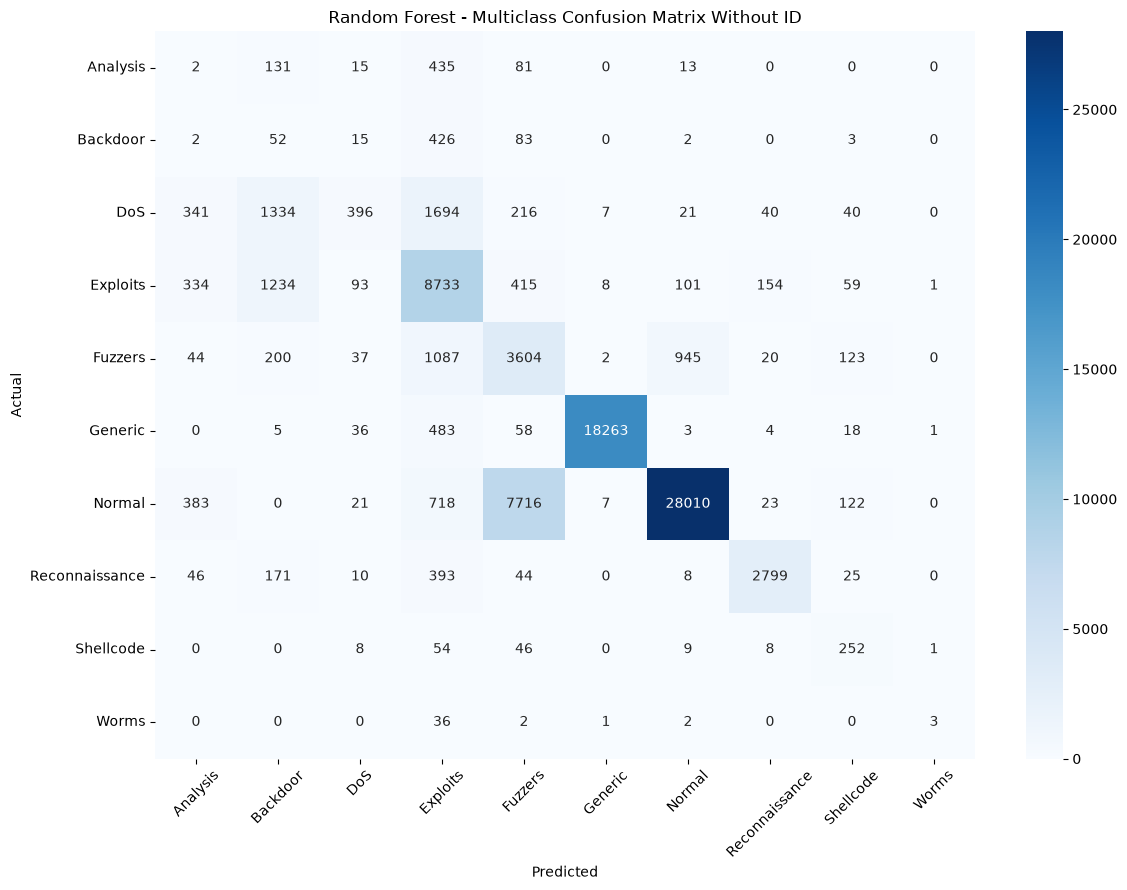

In [60]:
# Cell 105: Random Forest Confusion Matrix Without ID

cm_rf_no_id = confusion_matrix(
    y_test_multi_encoded,
    y_pred_multi_rf_no_id
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_rf_no_id,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Multiclass Confusion Matrix Without ID")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Multiclass Logistic Regression Without ID

In [45]:
# Cell 106: Multiclass Logistic Regression Without ID

multi_logistic_model_no_id = LogisticRegression(
    max_iter=1000,
    random_state=42
)

multi_logistic_model_no_id.fit(
    X_train_processed_no_id,
    y_train_multi_encoded
)

print("Multiclass Logistic Regression training without ID completed.")

Multiclass Logistic Regression training without ID completed.


## Logistic Regression Predictions Without ID

In [46]:
# Cell 107: Logistic Regression Predictions Without ID

y_pred_multi_logistic_no_id = (
    multi_logistic_model_no_id.predict(
        X_test_processed_no_id
    )
)

print("Logistic Regression predictions completed.")
print(
    "Number of predictions:",
    len(y_pred_multi_logistic_no_id)
)

Logistic Regression predictions completed.
Number of predictions: 82332


## Logistic Regression Evaluation Without ID

In [54]:
# Cell 108: Logistic Regression Evaluation Without ID

lr_no_id_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_logistic_no_id
)

lr_no_id_precision, lr_no_id_recall, lr_no_id_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_logistic_no_id,
        average="weighted",
        zero_division=0
    )
)

lr_no_id_macro_precision, lr_no_id_macro_recall, lr_no_id_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_logistic_no_id,
        average="macro",
        zero_division=0
    )
)

print("Logistic Regression Without ID Results")
print("---------------------------------------")
print("Accuracy          :", lr_no_id_accuracy)
print("Weighted Precision:", lr_no_id_precision)
print("Weighted Recall   :", lr_no_id_recall)
print("Weighted F1       :", lr_no_id_f1)
print("Macro Precision   :", lr_no_id_macro_precision)
print("Macro Recall      :", lr_no_id_macro_recall)
print("Macro F1          :", lr_no_id_macro_f1)

Logistic Regression Without ID Results
---------------------------------------
Accuracy          : 0.6983675849001604
Weighted Precision: 0.7940314150415938
Weighted Recall   : 0.6983675849001604
Weighted F1       : 0.7059588164791729
Macro Precision   : 0.3790078743966315
Macro Recall      : 0.3837623622915609
Macro F1          : 0.33528577387306296


## Logistic Regression Classification Report Without ID

In [111]:
# Cell 109: Logistic Regression Classification Report Without ID

print("Logistic Regression Classification Report Without ID")
print("======================================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_logistic_no_id,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Logistic Regression Classification Report Without ID
                precision    recall  f1-score   support

      Analysis       0.02      0.01      0.01       677
      Backdoor       0.00      0.00      0.00       583
           DoS       0.57      0.01      0.02      4089
      Exploits       0.53      0.80      0.64     11132
       Fuzzers       0.26      0.73      0.39      6062
       Generic       0.99      0.96      0.98     18871
        Normal       0.95      0.64      0.76     37000
Reconnaissance       0.47      0.69      0.56      3496
     Shellcode       0.00      0.00      0.00       378
         Worms       0.00      0.00      0.00        44

      accuracy                           0.70     82332
     macro avg       0.38      0.38      0.34     82332
  weighted avg       0.79      0.70      0.71     82332



## Multiclass XGBoost Without ID

In [41]:
# Cell 110: Multiclass XGBoost Without ID

multi_xgb_model_no_id = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

multi_xgb_model_no_id.fit(
    X_train_processed_no_id,
    y_train_multi_encoded
)

print("Multiclass XGBoost training without ID completed.")

Multiclass XGBoost training without ID completed.


## XGBoost Predictions Without ID

In [63]:
# Cell 111: XGBoost Predictions Without ID

y_pred_multi_xgb_no_id = (
    multi_xgb_model_no_id.predict(
        X_test_processed_no_id
    )
)

print("XGBoost predictions completed.")
print(
    "Number of predictions:",
    len(y_pred_multi_xgb_no_id)
)

XGBoost predictions completed.
Number of predictions: 82332


## XGBoost Evaluation Without ID

In [64]:
# Cell 112: XGBoost Evaluation Without ID

xgb_no_id_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_xgb_no_id
)

xgb_no_id_precision, xgb_no_id_recall, xgb_no_id_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_xgb_no_id,
        average="weighted",
        zero_division=0
    )
)

xgb_no_id_macro_precision, xgb_no_id_macro_recall, xgb_no_id_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_xgb_no_id,
        average="macro",
        zero_division=0
    )
)

print("XGBoost Without ID Results")
print("---------------------------")
print("Accuracy          :", xgb_no_id_accuracy)
print("Weighted Precision:", xgb_no_id_precision)
print("Weighted Recall   :", xgb_no_id_recall)
print("Weighted F1       :", xgb_no_id_f1)
print("Macro Precision   :", xgb_no_id_macro_precision)
print("Macro Recall      :", xgb_no_id_macro_recall)
print("Macro F1          :", xgb_no_id_macro_f1)

XGBoost Without ID Results
---------------------------
Accuracy          : 0.7697493076810961
Weighted Precision: 0.8351133858526978
Weighted Recall   : 0.7697493076810961
Weighted F1       : 0.778844691893989
Macro Precision   : 0.5326063989012251
Macro Recall      : 0.5414125477438968
Macro F1          : 0.4965508873397518


## XGBoost Evaluation Without ID

In [65]:
# Cell 112: XGBoost Evaluation Without ID

xgb_no_id_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_xgb_no_id
)

xgb_no_id_precision, xgb_no_id_recall, xgb_no_id_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_xgb_no_id,
        average="weighted",
        zero_division=0
    )
)

xgb_no_id_macro_precision, xgb_no_id_macro_recall, xgb_no_id_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_xgb_no_id,
        average="macro",
        zero_division=0
    )
)

print("XGBoost Without ID Results")
print("---------------------------")
print("Accuracy          :", xgb_no_id_accuracy)
print("Weighted Precision:", xgb_no_id_precision)
print("Weighted Recall   :", xgb_no_id_recall)
print("Weighted F1       :", xgb_no_id_f1)
print("Macro Precision   :", xgb_no_id_macro_precision)
print("Macro Recall      :", xgb_no_id_macro_recall)
print("Macro F1          :", xgb_no_id_macro_f1)

XGBoost Without ID Results
---------------------------
Accuracy          : 0.7697493076810961
Weighted Precision: 0.8351133858526978
Weighted Recall   : 0.7697493076810961
Weighted F1       : 0.778844691893989
Macro Precision   : 0.5326063989012251
Macro Recall      : 0.5414125477438968
Macro F1          : 0.4965508873397518


## XGBoost Classification Report Without ID

In [66]:
# Cell 113: XGBoost Classification Report Without ID

print("XGBoost Classification Report Without ID")
print("=========================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_xgb_no_id,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

XGBoost Classification Report Without ID
                precision    recall  f1-score   support

      Analysis       0.01      0.01      0.01       677
      Backdoor       0.03      0.07      0.04       583
           DoS       0.59      0.07      0.13      4089
      Exploits       0.58      0.89      0.70     11132
       Fuzzers       0.32      0.59      0.41      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.76      0.85     37000
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.31      0.79      0.45       378
         Worms       0.59      0.45      0.51        44

      accuracy                           0.77     82332
     macro avg       0.53      0.54      0.50     82332
  weighted avg       0.84      0.77      0.78     82332



## Final Corrected Model Comparison

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [67]:
# Cell 115: Recalculate Logistic Regression Metrics

y_pred_multi_logistic_no_id = (
    multi_logistic_model_no_id.predict(
        X_test_processed_no_id
    )
)

lr_no_id_accuracy = accuracy_score(
    y_test_multi_encoded,
    y_pred_multi_logistic_no_id
)

lr_no_id_precision, lr_no_id_recall, lr_no_id_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_logistic_no_id,
        average="weighted",
        zero_division=0
    )
)

lr_no_id_macro_precision, lr_no_id_macro_recall, lr_no_id_macro_f1, _ = (
    precision_recall_fscore_support(
        y_test_multi_encoded,
        y_pred_multi_logistic_no_id,
        average="macro",
        zero_division=0
    )
)

print("Logistic Regression Without ID Results")
print("---------------------------------------")
print("Accuracy          :", lr_no_id_accuracy)
print("Weighted Precision:", lr_no_id_precision)
print("Weighted Recall   :", lr_no_id_recall)
print("Weighted F1       :", lr_no_id_f1)
print("Macro Precision   :", lr_no_id_macro_precision)
print("Macro Recall      :", lr_no_id_macro_recall)
print("Macro F1          :", lr_no_id_macro_f1)

Logistic Regression Without ID Results
---------------------------------------
Accuracy          : 0.6983675849001604
Weighted Precision: 0.7940314150415938
Weighted Recall   : 0.6983675849001604
Weighted F1       : 0.7059588164791729
Macro Precision   : 0.3790078743966315
Macro Recall      : 0.3837623622915609
Macro F1          : 0.33528577387306296


In [75]:
# Cell 114: Final Model Comparison Without ID

final_results_no_id = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": lr_no_id_accuracy,
        "Weighted Precision": lr_no_id_precision,
        "Weighted Recall": lr_no_id_recall,
        "Weighted F1": lr_no_id_f1,
        "Macro Precision": lr_no_id_macro_precision,
        "Macro Recall": lr_no_id_macro_recall,
        "Macro F1": lr_no_id_macro_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_no_id_accuracy,
        "Weighted Precision": rf_no_id_precision,
        "Weighted Recall": rf_no_id_recall,
        "Weighted F1": rf_no_id_f1,
        "Macro Precision": rf_no_id_macro_precision,
        "Macro Recall": rf_no_id_macro_recall,
        "Macro F1": rf_no_id_macro_f1
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_no_id_accuracy,
        "Weighted Precision": xgb_no_id_precision,
        "Weighted Recall": xgb_no_id_recall,
        "Weighted F1": xgb_no_id_f1,
        "Macro Precision": xgb_no_id_macro_precision,
        "Macro Recall": xgb_no_id_macro_recall,
        "Macro F1": xgb_no_id_macro_f1
    }
])

display(
    final_results_no_id.round(4)
)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.6984,0.7940,0.6984,0.7060,0.3790,0.3838,0.3353
1,Random Forest,0.7544,0.8392,0.7544,0.7760,0.5332,0.4828,0.4585
2,XGBoost,0.7697,0.8351,0.7697,0.7788,0.5326,0.5414,0.4966


## Final XGBoost Classification Report

In [69]:
# Cell 115: Final XGBoost Classification Report

print("Final XGBoost Classification Report")
print("====================================")

print(
    classification_report(
        y_test_multi_encoded,
        y_pred_multi_xgb_no_id,
        labels=range(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Final XGBoost Classification Report
                precision    recall  f1-score   support

      Analysis       0.01      0.01      0.01       677
      Backdoor       0.03      0.07      0.04       583
           DoS       0.59      0.07      0.13      4089
      Exploits       0.58      0.89      0.70     11132
       Fuzzers       0.32      0.59      0.41      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.76      0.85     37000
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.31      0.79      0.45       378
         Worms       0.59      0.45      0.51        44

      accuracy                           0.77     82332
     macro avg       0.53      0.54      0.50     82332
  weighted avg       0.84      0.77      0.78     82332



## Final XGBoost Confusion Matrix

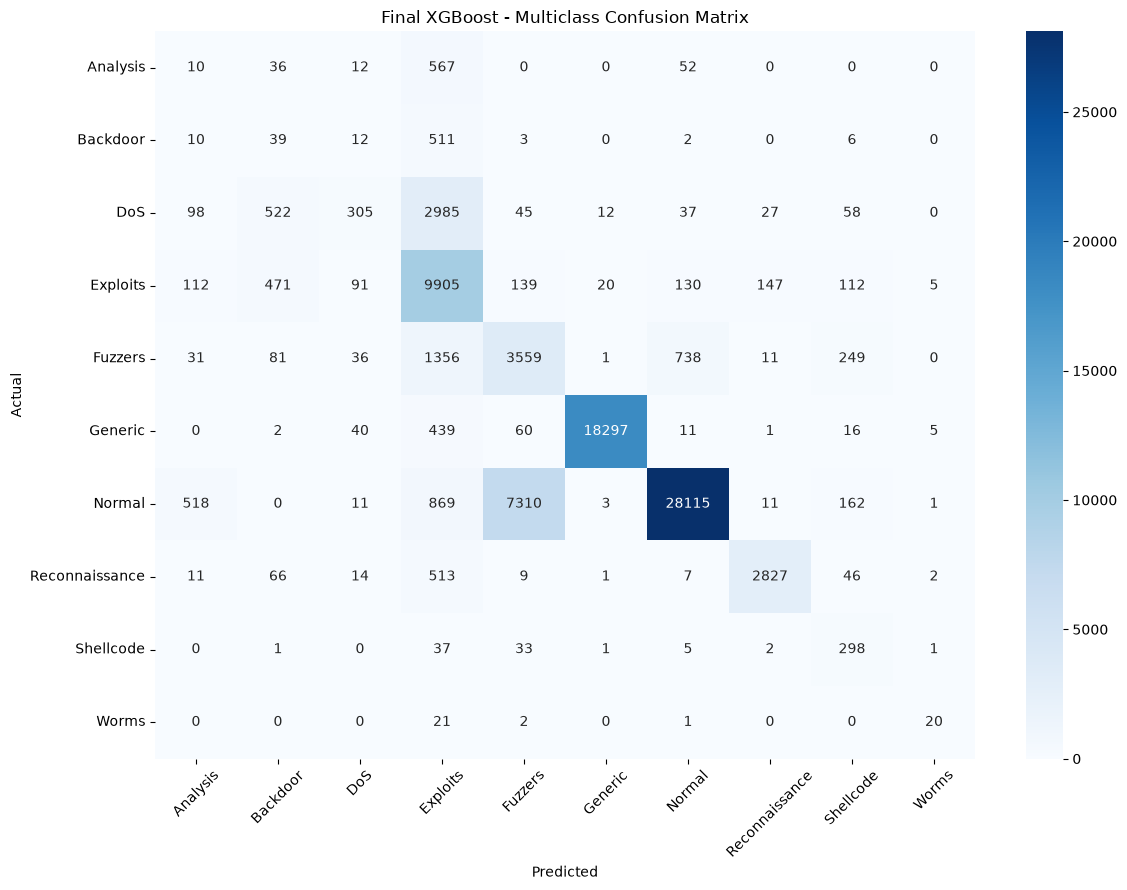

In [76]:
# Cell 116: Final XGBoost Confusion Matrix

cm_xgb_final = confusion_matrix(
    y_test_multi_encoded,
    y_pred_multi_xgb_no_id
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_xgb_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost - Multiclass Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## XGBoost Feature Importance

In [71]:
# Cell 117: XGBoost Feature Importance

xgb_importances = multi_xgb_model_no_id.feature_importances_

# Get feature names
categorical_feature_names_no_id = (
    encoder_no_id.get_feature_names_out(
        categorical_columns_no_id
    )
)

feature_names_no_id = (
    numerical_columns_no_id
    + list(categorical_feature_names_no_id)
)

xgb_feature_importance_df = pd.DataFrame({
    "Feature": feature_names_no_id,
    "Importance": xgb_importances
})

xgb_feature_importance_df = (
    xgb_feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("Number of features:", len(feature_names_no_id))
print("Number of importances:", len(xgb_importances))

print("\nTop 20 XGBoost Features")
print("=======================")

display(
    xgb_feature_importance_df.head(20)
)

Number of features: 194
Number of importances: 194

Top 20 XGBoost Features


,Feature,Importance
31,ct_dst_sport_ltm,0.208835
28,ct_state_ttl,0.127083
6,sttl,0.112203
174,service_dns,0.063283
7,dttl,0.047330
159,proto_unas,0.046091
158,proto_udp,0.036950
37,ct_srv_dst,0.022137
187,state_FIN,0.018613
24,dmean,0.018256


## XGBoost Feature Importance Graph

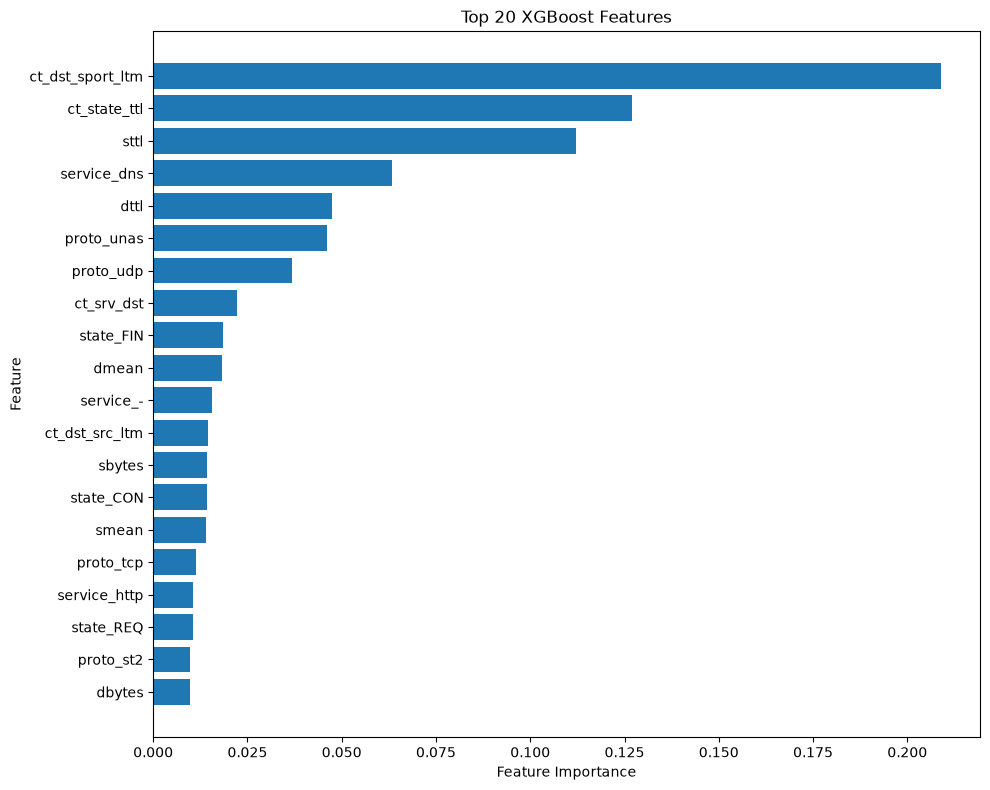

In [72]:
# Cell 118: Top 20 XGBoost Feature Importance

top_xgb_features = xgb_feature_importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_xgb_features["Feature"][::-1],
    top_xgb_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

## Save Final Model Information

In [73]:
# Cell 119: Recreate Final XGBoost Model Without ID

from xgboost import XGBClassifier

multi_xgb_model_no_id = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

multi_xgb_model_no_id.fit(
    X_train_processed_no_id,
    y_train_multi_encoded
)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


## Save Final Model

In [4]:
import joblib

In [80]:
# Cell 121: Load Final Model Package

import joblib

final_model_package = joblib.load(
    "final_network_security_xgboost.pkl"
)

final_model = final_model_package["model"]
final_encoder = final_model_package["encoder"]
final_scaler = final_model_package["scaler"]
final_categorical_columns = final_model_package["categorical_columns"]
final_numerical_columns = final_model_package["numerical_columns"]
final_label_encoder = final_model_package["label_encoder"]

print("Final model package loaded successfully.")

print("Categorical columns:", final_categorical_columns)
print("Number of numerical columns:", len(final_numerical_columns))
print("Number of classes:", len(final_label_encoder.classes_))
print("Classes:", list(final_label_encoder.classes_))

Final model package loaded successfully.
Categorical columns: ['proto', 'service', 'state']
Number of numerical columns: 39
Number of classes: 10
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [79]:
# Cell 120: Save Final XGBoost Model

model_path = "final_network_security_xgboost.pkl"

joblib.dump(
    final_model_package,
    model_path
)

print("Final model saved successfully.")
print("File:", model_path)

Final model saved successfully.
File: final_network_security_xgboost.pkl


## Create Risk Score Function

In [81]:
# Cell 122: Risk Score Function

def calculate_risk_score(attack_category, confidence):
    """
    Calculate a project-level cybersecurity risk score.

    Parameters:
        attack_category : predicted attack category
        confidence      : model prediction confidence (0 to 1)

    Returns:
        risk_score      : score from 0 to 100
        severity        : LOW / MEDIUM / HIGH / CRITICAL
    """

    # Base risk associated with attack category
    base_risk = {
        "Normal": 10,
        "Analysis": 35,
        "Reconnaissance": 45,
        "Fuzzers": 55,
        "Generic": 60,
        "DoS": 70,
        "Exploits": 80,
        "Backdoor": 85,
        "Shellcode": 90,
        "Worms": 95
    }

    base_score = base_risk.get(
        attack_category,
        50
    )

    # Adjust risk according to model confidence
    risk_score = base_score * confidence

    # Keep score between 0 and 100
    risk_score = max(
        0,
        min(100, risk_score)
    )

    # Determine severity
    if risk_score <= 30:
        severity = "LOW"
    elif risk_score <= 60:
        severity = "MEDIUM"
    elif risk_score <= 80:
        severity = "HIGH"
    else:
        severity = "CRITICAL"

    return round(risk_score, 2), severity

## Create Prediction Function

In [82]:
# Cell 123: Network Security Incident Prediction Function

import pandas as pd
import numpy as np


def predict_incident(network_record):
    """
    Predict the attack category for a network traffic record.

    Parameters:
        network_record : dictionary containing network traffic features

    Returns:
        dictionary containing:
        - predicted attack category
        - confidence
        - risk score
        - severity
    """

    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([network_record])

    # Remove ID if supplied
    if "id" in input_df.columns:
        input_df = input_df.drop(columns=["id"])

    # Check required columns
    required_columns = (
        final_numerical_columns +
        final_categorical_columns
    )

    missing_columns = [
        col for col in required_columns
        if col not in input_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing required features: "
            + str(missing_columns)
        )

    # Keep only features used by the model
    input_df = input_df[required_columns]

    # Process categorical features
    categorical_data = final_encoder.transform(
        input_df[final_categorical_columns]
    )

    # Process numerical features
    numerical_data = final_scaler.transform(
        input_df[final_numerical_columns]
    )

    # Combine processed features
    processed_input = np.hstack([
        numerical_data,
        categorical_data
    ])

    # Predict encoded class
    predicted_encoded = final_model.predict(
        processed_input
    )[0]

    # Convert encoded class to original attack name
    predicted_category = final_label_encoder.inverse_transform(
        [int(predicted_encoded)]
    )[0]

    # Get prediction probabilities
    probabilities = final_model.predict_proba(
        processed_input
    )[0]

    # Get confidence
    confidence = float(
        np.max(probabilities)
    )

    # Calculate risk
    risk_score, severity = calculate_risk_score(
        predicted_category,
        confidence
    )

    return {
        "predicted_attack": predicted_category,
        "confidence": round(confidence, 4),
        "risk_score": risk_score,
        "severity": severity
    }

## Test With a Real Test Dataset Record

In [83]:
# Cell 124: Test Prediction Using Real Test Record

sample_record = test.iloc[0].to_dict()

# Remove target columns because they are not input features
sample_record.pop("label", None)
sample_record.pop("attack_cat", None)

prediction_result = predict_incident(
    sample_record
)

print("Prediction Result")
print("==================")

for key, value in prediction_result.items():
    print(f"{key}: {value}")

Prediction Result
predicted_attack: Fuzzers
confidence: 0.4314
risk_score: 23.73
severity: LOW


## Compare Prediction With Actual Label

In [84]:
# Cell 125: Compare Predicted and Actual Attack

actual_category = test.iloc[0]["attack_cat"]

print("Actual Attack Category   :", actual_category)
print("Predicted Attack Category:", prediction_result["predicted_attack"])
print("Confidence               :", prediction_result["confidence"])
print("Risk Score               :", prediction_result["risk_score"])
print("Severity                 :", prediction_result["severity"])

if actual_category == prediction_result["predicted_attack"]:
    print("\nPrediction Status: Correct")
else:
    print("\nPrediction Status: Incorrect")

Actual Attack Category   : Normal
Predicted Attack Category: Fuzzers
Confidence               : 0.4314
Risk Score               : 23.73
Severity                 : LOW

Prediction Status: Incorrect


## Test Multiple Network Records

In [85]:
# Cell 126: Test Multiple Network Records

prediction_results = []

for index in range(10):

    sample_record = test.iloc[index].to_dict()

    actual_category = sample_record.get(
        "attack_cat"
    )

    sample_record.pop("label", None)
    sample_record.pop("attack_cat", None)

    result = predict_incident(
        sample_record
    )

    result["actual_attack"] = actual_category
    result["record_number"] = index + 1

    prediction_results.append(result)

prediction_results_df = pd.DataFrame(
    prediction_results
)

display(prediction_results_df)

,predicted_attack,confidence,risk_score,severity,actual_attack,record_number
0,Fuzzers,0.4314,23.73,LOW,Normal,1
1,Fuzzers,0.7214,39.68,MEDIUM,Normal,2
2,Fuzzers,0.7008,38.55,MEDIUM,Normal,3
3,Fuzzers,0.6990,38.45,MEDIUM,Normal,4
4,Fuzzers,0.7385,40.61,MEDIUM,Normal,5
5,Fuzzers,0.8019,44.10,MEDIUM,Normal,6
6,Fuzzers,0.7658,42.12,MEDIUM,Normal,7
7,Fuzzers,0.4750,26.12,LOW,Normal,8
8,Normal,0.9990,9.99,LOW,Normal,9
9,Normal,0.9990,9.99,LOW,Normal,10


## Prediction Accuracy on Sample

In [86]:
# Cell 127: Sample Prediction Accuracy

sample_accuracy = (
    prediction_results_df["actual_attack"]
    ==
    prediction_results_df["predicted_attack"]
).mean()

print(
    "Prediction accuracy on 10 test records:",
    round(sample_accuracy * 100, 2),
    "%"
)

Prediction accuracy on 10 test records: 20.0 %


## Show Prediction Probabilities

In [87]:
# Cell 128: Detailed Prediction Probabilities

def predict_incident_with_probabilities(network_record):

    input_df = pd.DataFrame([network_record])

    if "id" in input_df.columns:
        input_df = input_df.drop(columns=["id"])

    required_columns = (
        final_numerical_columns +
        final_categorical_columns
    )

    input_df = input_df[required_columns]

    categorical_data = final_encoder.transform(
        input_df[final_categorical_columns]
    )

    numerical_data = final_scaler.transform(
        input_df[final_numerical_columns]
    )

    processed_input = np.hstack([
        numerical_data,
        categorical_data
    ])

    probabilities = final_model.predict_proba(
        processed_input
    )[0]

    probability_df = pd.DataFrame({
        "Attack Category": final_label_encoder.classes_,
        "Probability": probabilities
    })

    probability_df["Probability"] = (
        probability_df["Probability"] * 100
    ).round(2)

    probability_df = probability_df.sort_values(
        by="Probability",
        ascending=False
    )

    return probability_df

## Test Probability Distribution

In [88]:
# Cell 129: Test Prediction Probabilities

sample_record = test.iloc[0].to_dict()

sample_record.pop("label", None)
sample_record.pop("attack_cat", None)

probability_result = (
    predict_incident_with_probabilities(
        sample_record
    )
)

display(probability_result)

,Attack Category,Probability
4,Fuzzers,43.139999
6,Normal,18.030001
8,Shellcode,16.170000
3,Exploits,13.940000
2,DoS,6.420000
5,Generic,1.500000
7,Reconnaissance,0.670000
1,Backdoor,0.080000
0,Analysis,0.050000
9,Worms,0.020000
